# Lab 2: CNN for Image Classification (PetFinder)

**Name:** *Matt Hunter and Darren Sluss*

This notebook has no starter code. Each section below tells you what to build and what questions to answer in your own words, but the code itself is yours to write. Use the CNN Fundamentals lecture and Lab 1 as your reference for syntax, not as something to copy from.

**Submission:** GitHub repo URL + this notebook's URL on Canvas.

## Setup

Clone the course repo (or your fork) to access the dataset, then import the libraries you expect to need. You will likely want `pandas`, `numpy`, `os`, image-loading tools (for example `PIL.Image`), `matplotlib`, `tensorflow`, and evaluation tools from `sklearn`. Add imports as you go, you don't need to guess all of them up front.

In [ ]:
# Clone the repo to access the data (only needs to run once per Colab session)
# !git clone <your-fork-url>


In [2]:
# Your imports here

import pandas as pd
import numpy as np
import os
import PIL.Image
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import confusion_matrix
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.utils import to_categorical


---
## Part A: Load and Prepare the Data

**What to do:**
1. Load `train.csv` and inspect it. You need the `PetID` and `Type` columns (`Type`: 1 = Dog, 2 = Cat).
2. Write code that loads each pet's primary photo from `train_images/`, resizes it to a consistent size of your choosing, and normalizes pixel values.
3. Build your `X` (images) and `y` (Dog/Cat) arrays.
4. Split into train and test sets. Decide, and justify, whether you need to stratify this split.
5. Report how many images you ended up with, and whether Dog and Cat are reasonably balanced.

**Note:** not every `PetID` in `train.csv` will have a matching photo file. Your loading code should skip missing images gracefully rather than erroring out.

**Answer in this notebook:**
- What image size did you choose, and why?
- Did you stratify your train/test split? Why or why not?


In [3]:
# Load train.csv here

#Load and preprocess data
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

#Normalize pixel values (0-255) -> (0-1)
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

#One hot encode labels (0-9)
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
# Write your image-loading function here

In [ ]:
# Build X and y, then split into train/test here

*Your written answers for Part A:*

- Image size chosen and why:
- Stratification decision and why:


---
## Part B: Build a CNN From Scratch

**What to decide, and be ready to justify:**
- How many Conv2D and MaxPooling2D layers will you use?
- How many filters at each layer, and how does that number change as you go deeper?
- What kernel size will you use, and why?
- What does your Dense classifier head look like after the Flatten layer?
- What output layer and activation fits a Dog vs. Cat task specifically? Is this the same as Lab 1's binary classification setup, or different?

Write your architecture below, then write one paragraph justifying every choice, using the conventions from lecture (filters growing with depth, 3x3 kernels, funnel-shaped Dense layers, and so on).

In [16]:
# Build your CNN model here

model = Sequential()

# 1st CNN layer - #filters = 32, filter_size = 3
model.add(Conv2D(32, kernel_size = 3, activation= 'relu', input_shape = (28, 28, 1)))

# Pooling layer - max pooling, pooling filter size 2 x 2 and stride = 2
model.add(MaxPooling2D(pool_size = 2, strides = 2))

# 2nd CNN layer - #filters = 64, filter_size = 3
model.add(Conv2D(64, kernel_size= 3, activation= 'relu'))

# Pooling layer - max pooling, pooling filter size 2 x 2 and stride = 2
model.add(MaxPooling2D(pool_size = 2, strides = 2))

# Flatten the feature maps
model.add(Flatten())

# Fully connected output layer
model.add(Dense(10, activation= 'softmax'))



In [17]:
# Compile your model here

model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])


*Your architecture justification (one paragraph):*

This sequential CNN uses two convolutional blocks with $3 \times 3$ kernels and ReLU activation to extract spatial features like edges and textures, followed by max pooling layers to downsample the feature maps. The Flatten layer then converts these 2D spatial maps into a 1D vector to feed into the dense output layer, which uses a 10-class softmax activation for multi-class classification.




---
## Part C: Train and Diagnose

**What to do:**
1. Train your model, saving the history.
2. Plot training vs. validation loss and accuracy.
3. Diagnose the fit: good fit, overfitting, or underfitting? Point to specific evidence from your own curve.
4. Evaluate on the test set and report accuracy.

In [18]:
# Train your model here (save the result as `history`)

history = model.fit(
    x_train, y_train,
    batch_size=64,
    epochs=5,
    validation_split=0.2
)

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 43s 56ms/step - accuracy: 0.8002 - loss: 0.5559 - val_accuracy: 0.8617 - val_loss: 0.3943
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 84s 59ms/step - accuracy: 0.8680 - loss: 0.3717 - val_accuracy: 0.8741 - val_loss: 0.3488
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 55ms/step - accuracy: 0.8828 - loss: 0.3274 - val_accuracy: 0.8832 - val_loss: 0.3181
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 83s 57ms/step - accuracy: 0.8930 - loss: 0.2976 - val_accuracy: 0.8883 - val_loss: 0.3094
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 46s 61ms/step - accuracy: 0.9007 - loss: 0.2772 - val_accuracy: 0.8934 - val_loss: 0.2951


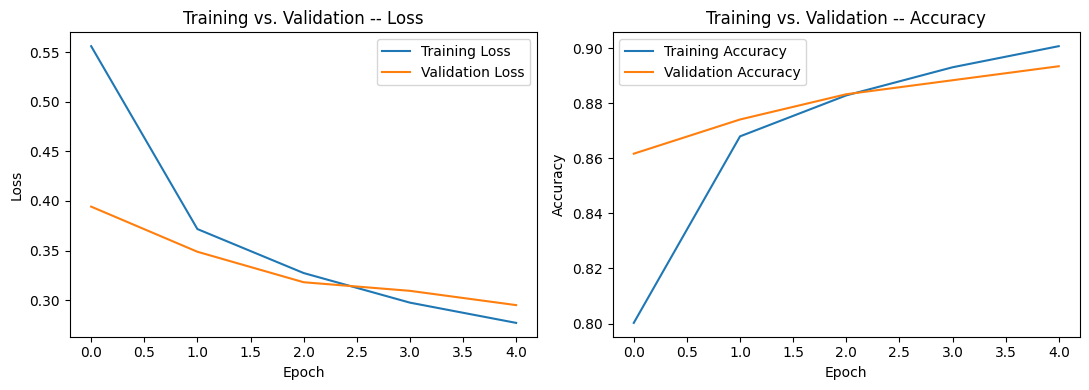

In [19]:
# Plot training vs. validation loss and accuracy

def plot_history(history, title, show_accuracy=False):
    if show_accuracy:
        fig, axes = plt.subplots(1, 2, figsize=(11, 4))
        axes[0].plot(history.history["loss"], label="Training Loss")
        axes[0].plot(history.history["val_loss"], label="Validation Loss")
        axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()
        axes[0].set_title(title + " -- Loss")

        axes[1].plot(history.history["accuracy"], label="Training Accuracy")
        axes[1].plot(history.history["val_accuracy"], label="Validation Accuracy")
        axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend()
        axes[1].set_title(title + " -- Accuracy")
        plt.tight_layout()
        plt.show()
    else:
        plt.figure(figsize=(6, 4))
        plt.plot(history.history["loss"], label="Training Loss")
        plt.plot(history.history["val_loss"], label="Validation Loss")
        plt.xlabel("Epoch"); plt.ylabel("Loss (MSE, scaled)"); plt.title(title); plt.legend()
        plt.show()

plot_history(history, "Training vs. Validation", show_accuracy=True)

*Your fit diagnosis, with specific evidence from your curve:*

After looking at our curve, we think that this is a good fit because both the training and the validation loss is steadily decreasing and staying close to each other. The validation loss does not start to go up after some epochs and the training accuracy is about the same as the validation accuracy so we don't think it is overfitting.


In [20]:
# Evaluate on the test set and report accuracy here

test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.8857 - loss: 0.3174
Test Loss: 0.3174
Test Accuracy: 88.57%


---
## Part D: Improve the Model

Choose **one** path, based on what Part C showed you.

**If your baseline overfit:** apply Dropout, Early Stopping, or both, the same tools from Assignment 1, to your own CNN.

**If your baseline did not overfit, or you want to push accuracy further:** use Keras Tuner to search over at least 2 hyperparameters of your choosing. Keep the same test-set discipline from Assignment 1: tuning only touches training and validation data, the test set is touched once, at the end.

State which path you chose and why, before you start building it.

*Which path are you taking, and why:*




In [21]:
# Build your improved model here
from tensorflow.keras.layers import Dropout

model_improved = Sequential()

# 1st CNN layer + Dropout
model_improved.add(Conv2D(32, kernel_size=3, activation='relu', input_shape=(28, 28, 1)))
model_improved.add(MaxPooling2D(pool_size=2, strides=2))
model_improved.add(Dropout(0.25))

# 2nd CNN layer + Dropout
model_improved.add(Conv2D(64, kernel_size=3, activation='relu'))
model_improved.add(MaxPooling2D(pool_size=2, strides=2))
model_improved.add(Dropout(0.25))

# Flatten and Dense Head with Dropout
model_improved.add(Flatten())
model_improved.add(Dense(128, activation='relu'))
model_improved.add(Dropout(0.5))
model_improved.add(Dense(10, activation='softmax'))

model_improved.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [22]:
# Train your improved model here

from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Train your improved model here
history_improved = model_improved.fit(
    x_train, y_train,
    batch_size=64,
    epochs=20,
    validation_split=0.2,
    callbacks=[early_stopping]
)

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 56s 73ms/step - accuracy: 0.7450 - loss: 0.6896 - val_accuracy: 0.8404 - val_loss: 0.4432
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 51s 68ms/step - accuracy: 0.8325 - loss: 0.4603 - val_accuracy: 0.8722 - val_loss: 0.3435
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.8512 - loss: 0.4080

KeyboardInterrupt: 

---
## Part E: Compare and Evaluate

Fill in your own results:

| | Baseline CNN | Improved CNN |
|---|---|---|
| Test accuracy | | |
| Fit pattern (good/over/under) | | |
| What changed | | |

Report a confusion matrix for your improved model. Are Dogs or Cats more often misclassified? Do you have a guess as to why, based on looking at a few misclassified photos directly?

In [ ]:
# Evaluate your improved model and build a confusion matrix here



*Your discussion of the confusion matrix:*




---
## Part F: Look at Your Mistakes

Pull 3 to 5 images your model got wrong and display them. Write 2 to 3 sentences: is there anything visually in common among the photos your model struggled with, unusual angles, poor lighting, multiple animals in frame, something else?

In [ ]:
# Find and display misclassified images here



*Your observations about the misclassified images:*




---
## Done!

Save this notebook back to your GitHub fork, then submit your two links on Canvas.